In [1]:
import pandas as pd
import numpy as np
import random
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import os
from fastai.tabular.all import *
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## Load Data

In [3]:
df = pd.read_csv('./data/Gaming_Academic_Performance.csv')
print(f"Shape: {df.shape}")
df.head()

Shape: (8000, 14)


,student_id,age,gender,gaming_hours,study_hours,sleep_hours,attendance,gaming_genre,social_activity,device_usage,reaction_time_ms,addiction_score,stress_level,grades
0,1,22,Male,7.23,8.78,6.96,91.44,FPS,3.25,9.36,235.84,14.69,Low,86.459555
1,2,19,Male,0.07,8.72,7.63,63.63,Casual,1.02,3.21,328.71,2.47,Medium,98.230000
2,3,23,Female,1.73,9.56,4.40,83.26,Casual,3.46,5.56,313.61,4.73,High,90.560000
3,4,20,Female,6.62,1.68,7.83,75.04,RPG,1.46,11.78,241.84,14.54,Low,32.670000
4,5,22,Female,5.36,5.83,5.55,65.57,FPS,1.01,8.23,249.31,12.48,Low,58.710000


In [4]:
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "No missing values")

No missing values


In [5]:
test_df = df.sample(frac=0.1, random_state=42)
main_df = df.drop(test_df.index).reset_index(drop=True)
test_df = test_df.reset_index(drop=True)
print(f"Train: {len(main_df)}, Test: {len(test_df)}")

Train: 7200, Test: 800


## Correlation Heatmap

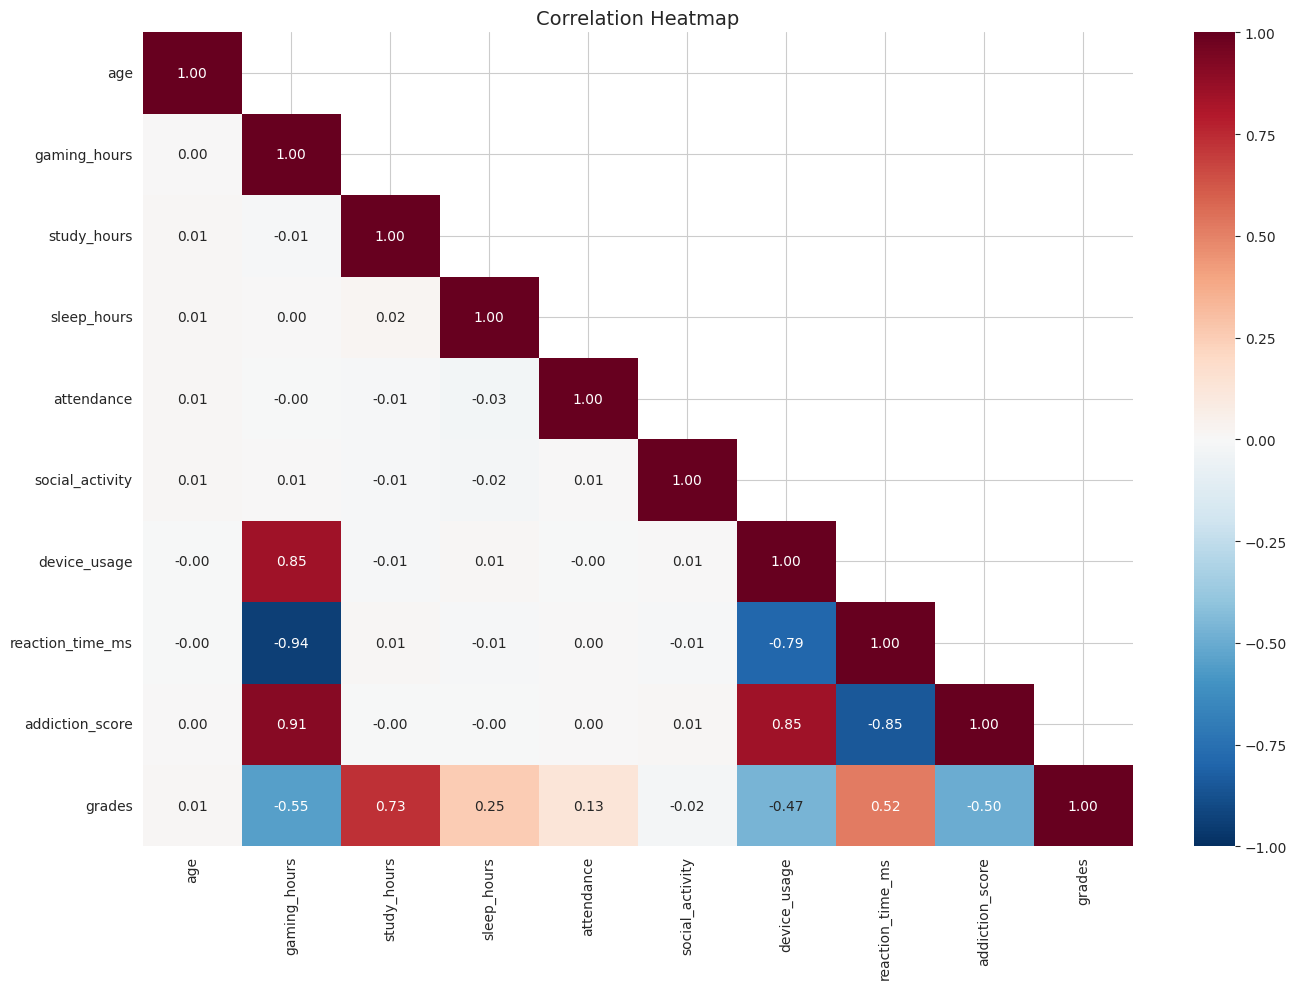

In [6]:
plt.figure(figsize=(14, 10))
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in ['student_id']]
corr = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, cmap='RdBu_r', center=0, fmt='.2f', vmin=-1, vmax=1)
plt.title('Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

## Target Distribution

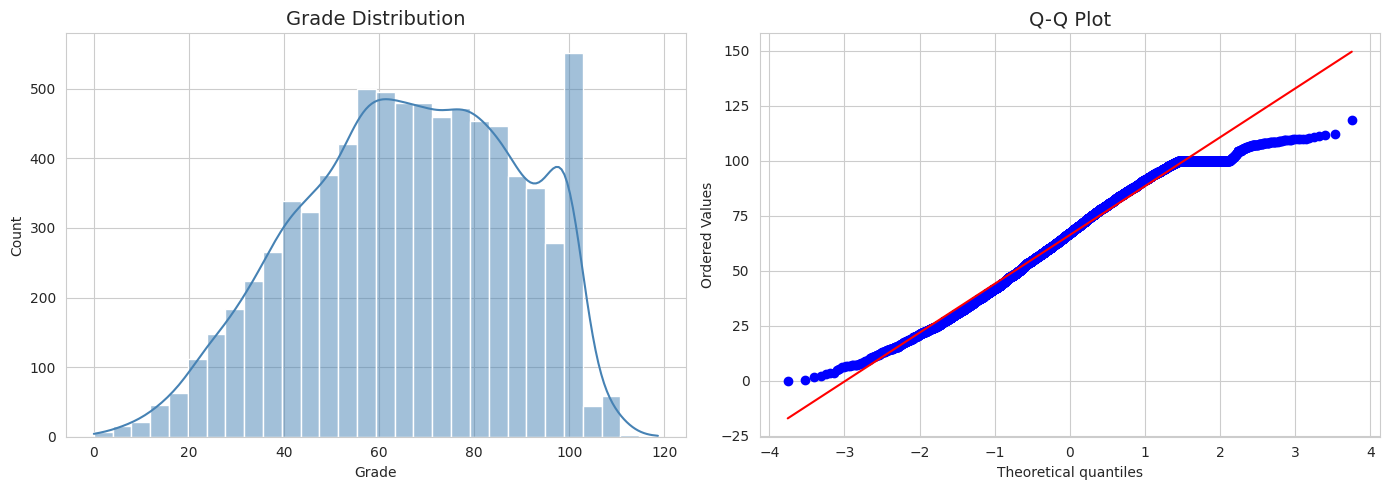

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['grades'], bins=30, kde=True, color='steelblue', ax=axes[0])
axes[0].set_title('Grade Distribution', fontsize=14)
axes[0].set_xlabel('Grade')

stats.probplot(df['grades'], dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot', fontsize=14)
plt.tight_layout()
plt.show()

## Gaming Hours vs Grades

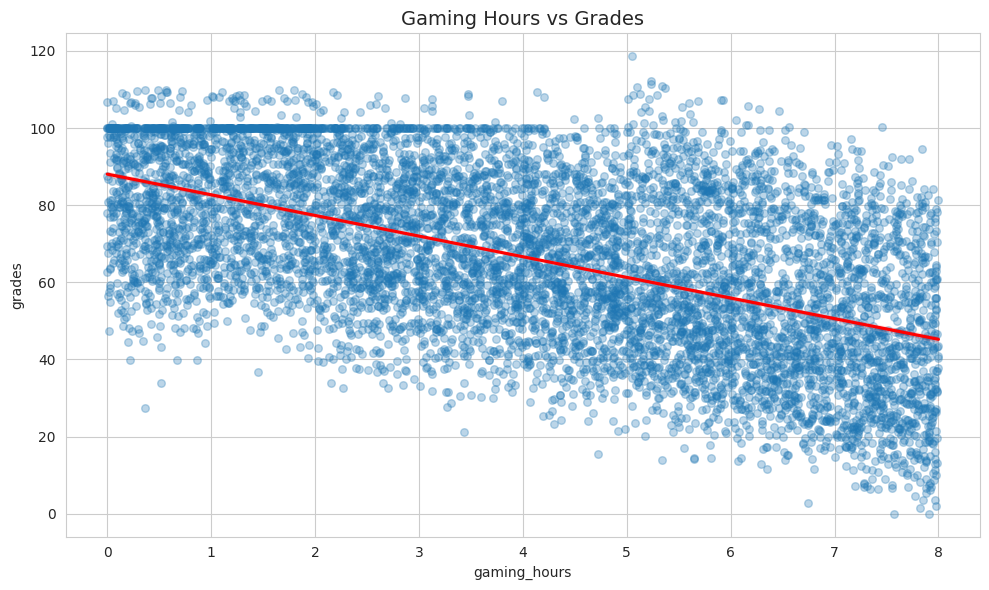

In [8]:
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='gaming_hours', y='grades', scatter_kws={'alpha':0.3, 's':30}, line_kws={'color':'red'})
plt.title('Gaming Hours vs Grades', fontsize=14)
plt.tight_layout()
plt.show()

## Feature Distributions

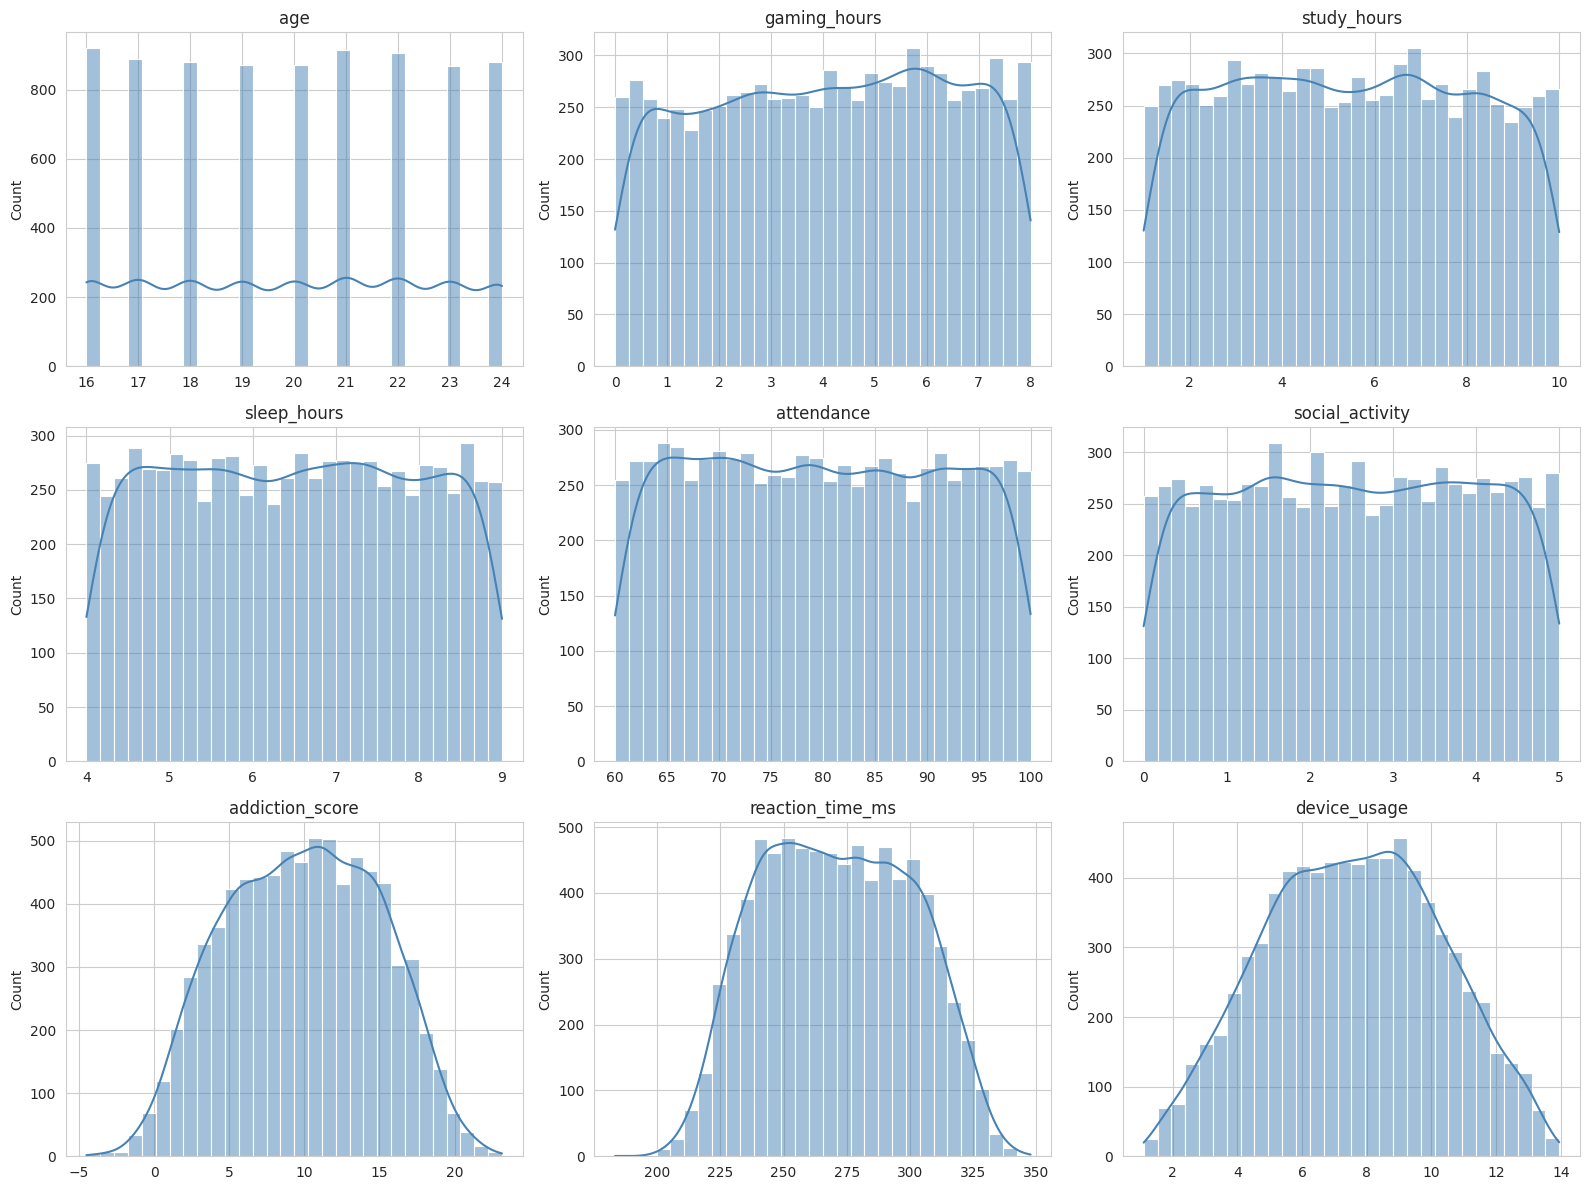

In [9]:
cont_features = ['age', 'gaming_hours', 'study_hours', 'sleep_hours', 'attendance', 'social_activity', 'addiction_score', 'reaction_time_ms', 'device_usage']
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()
for i, col in enumerate(cont_features):
    sns.histplot(df[col], bins=30, kde=True, color='steelblue', ax=axes[i])
    axes[i].set_title(col, fontsize=12)
    axes[i].set_xlabel('')
plt.tight_layout()
plt.show()

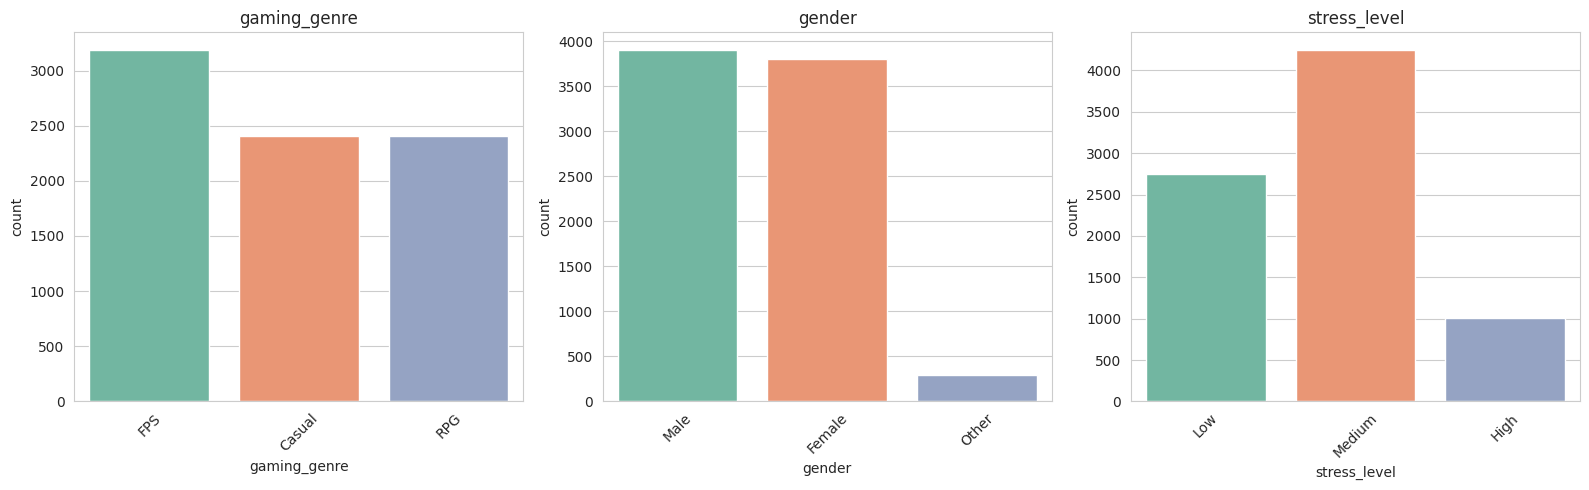

In [10]:
cat_features = ['gaming_genre', 'gender', 'stress_level']
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for i, col in enumerate(cat_features):
    sns.countplot(data=df, x=col, hue=col, palette='Set2', ax=axes[i], legend=False)
    axes[i].set_title(col, fontsize=12)
    axes[i].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

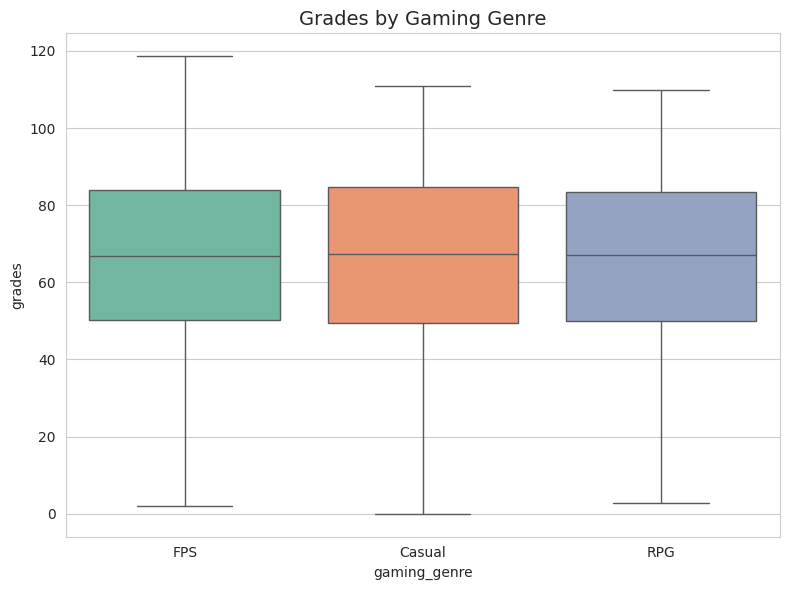

In [11]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='gaming_genre', y='grades', palette='Set2')
plt.title('Grades by Gaming Genre', fontsize=14)
plt.tight_layout()
plt.show()

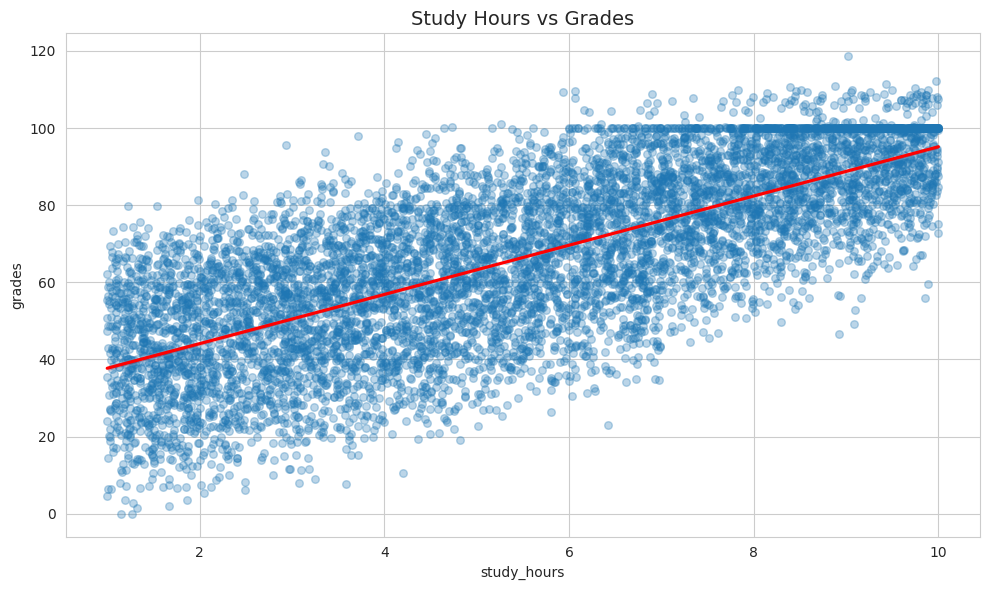

In [12]:
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='study_hours', y='grades', scatter_kws={'alpha':0.3, 's':30}, line_kws={'color':'red'})
plt.title('Study Hours vs Grades', fontsize=14)
plt.tight_layout()
plt.show()

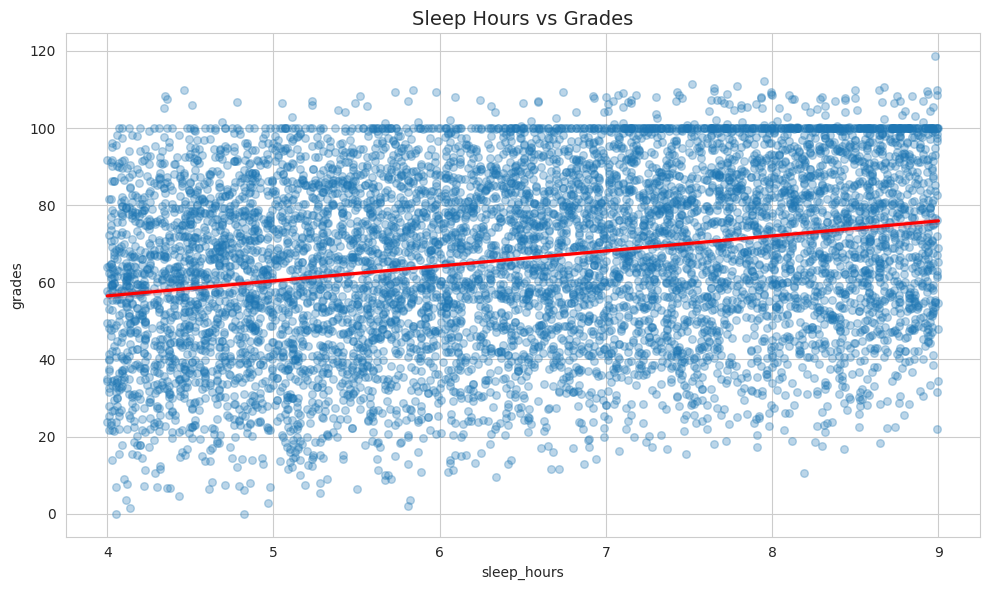

In [13]:
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='sleep_hours', y='grades', scatter_kws={'alpha':0.3, 's':30}, line_kws={'color':'red'})
plt.title('Sleep Hours vs Grades', fontsize=14)
plt.tight_layout()
plt.show()

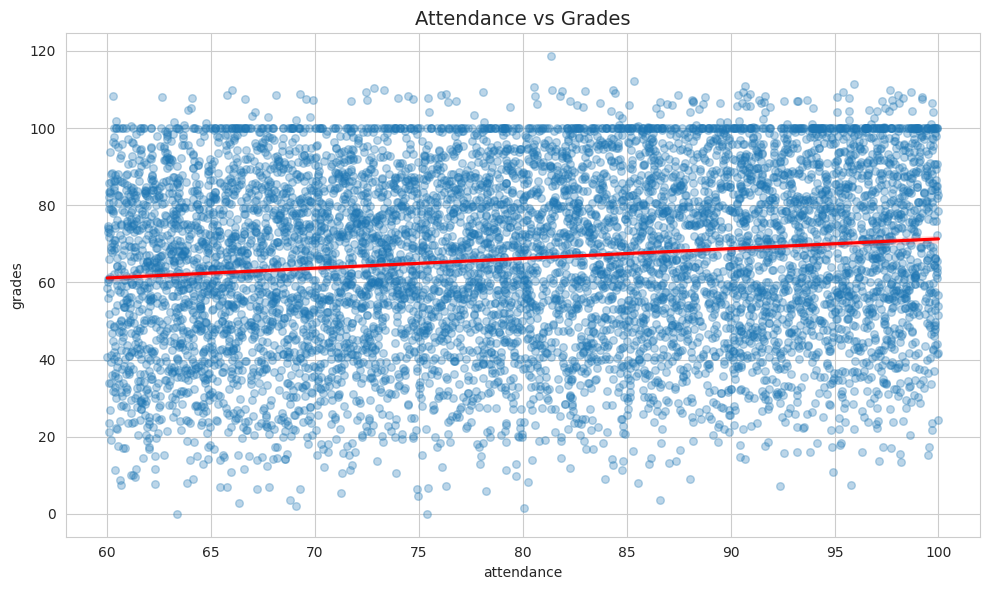

In [14]:
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='attendance', y='grades', scatter_kws={'alpha':0.3, 's':30}, line_kws={'color':'red'})
plt.title('Attendance vs Grades', fontsize=14)
plt.tight_layout()
plt.show()

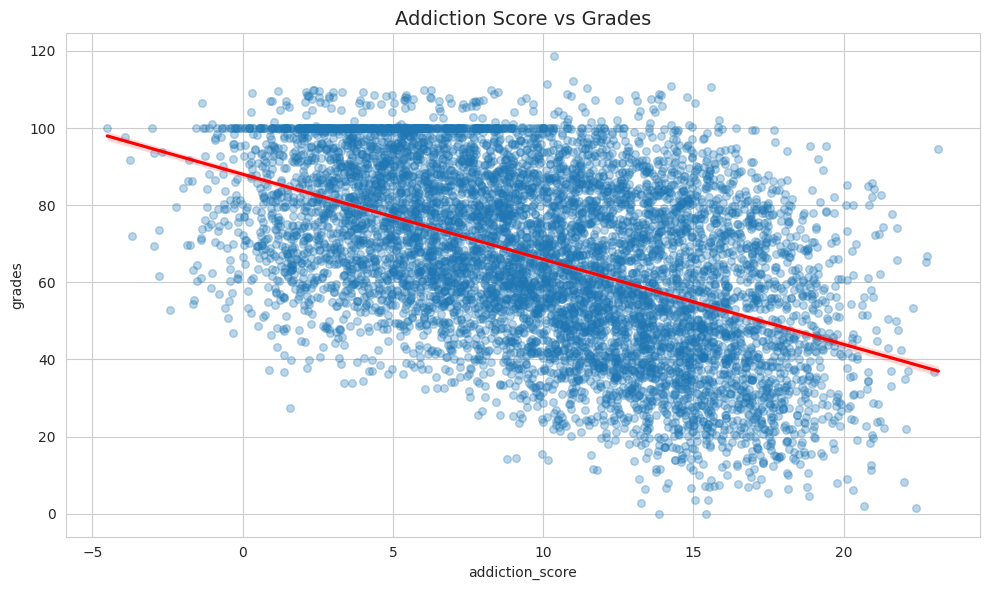

In [15]:
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='addiction_score', y='grades', scatter_kws={'alpha':0.3, 's':30}, line_kws={'color':'red'})
plt.title('Addiction Score vs Grades', fontsize=14)
plt.tight_layout()
plt.show()

## Preprocessing

In [16]:
cat_names = ['gaming_genre', 'gender', 'stress_level']
cont_names = [
    'age', 'gaming_hours', 'sleep_hours',
    'study_hours', 'attendance', 'social_activity',
    'addiction_score', 'reaction_time_ms', 'device_usage'
]
y_names = 'grades'
procs = [Categorify, FillMissing, Normalize]
print(f"Categorical: {cat_names}")
print(f"Continuous: {cont_names}")

Categorical: ['gaming_genre', 'gender', 'stress_level']
Continuous: ['age', 'gaming_hours', 'sleep_hours', 'study_hours', 'attendance', 'social_activity', 'addiction_score', 'reaction_time_ms', 'device_usage']


In [17]:
dls = TabularDataLoaders.from_df(
    main_df,
    path='./',
    y_names=y_names,
    cat_names=cat_names,
    cont_names=cont_names,
    procs=procs,
    valid_pct=0.2,
    seed=42,
    bs=128
)
dls.show_batch()

,gaming_genre,gender,stress_level,age,gaming_hours,sleep_hours,study_hours,attendance,social_activity,addiction_score,reaction_time_ms,device_usage,grades
0,Casual,Female,Low,17.0,5.77,4.99,3.77,83.019997,0.70,14.370000,246.160003,11.52,44.560001
1,RPG,Other,Medium,17.0,1.72,7.50,5.74,93.870002,2.96,5.430000,292.320007,4.73,93.839996
2,FPS,Male,High,17.0,4.61,5.99,7.77,97.059998,0.88,12.600000,262.679993,10.49,69.900002
3,Casual,Female,Medium,24.0,1.35,4.35,6.94,63.160000,4.09,5.650000,304.380007,6.53,77.790001
4,RPG,Female,Medium,22.0,3.73,7.82,8.88,78.129997,3.20,8.400000,282.480011,8.56,101.495811
5,FPS,Male,Low,24.0,7.04,6.03,4.29,91.349999,3.07,19.280001,230.449997,12.07,43.560001
6,FPS,Female,Low,23.0,5.75,6.76,8.36,68.180000,0.69,12.610000,258.160004,7.96,88.628220
7,Casual,Male,Low,23.0,6.24,7.73,2.73,62.779999,4.63,14.930000,248.600006,10.35,34.700001
8,FPS,Male,Medium,21.0,1.56,6.03,3.74,61.290001,1.99,6.710000,305.079987,6.27,73.106857
9,RPG,Female,Medium,21.0,2.17,4.65,2.81,64.529998,0.77,7.270000,286.950012,6.01,48.259998


## Learning Rate Finder

<div></div>

Suggested LR: 0.0014454397605732083


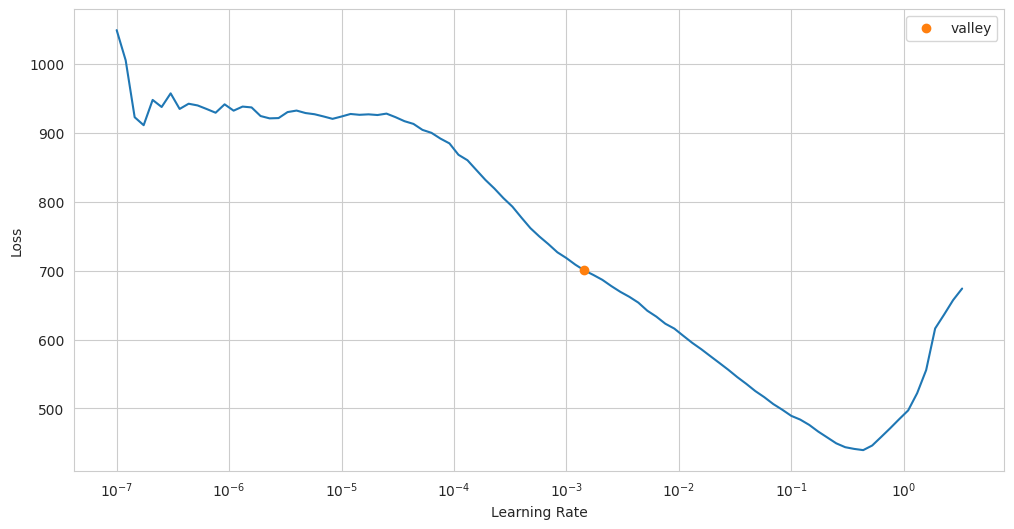

In [18]:
learn = tabular_learner(
    dls,
    layers=[300, 150],
    metrics=[rmse],
    y_range=(0, 100),
    config={'ps': 0.1},
    wd=0.1
)
suggestions = learn.lr_find()
print(f"Suggested LR: {suggestions.valley}")

## Training

In [19]:
early_stopping = EarlyStoppingCallback(monitor='valid_loss', patience=5)
learn.fit_one_cycle(50, lr_max=suggestions.valley, cbs=early_stopping)

epoch,train_loss,valid_loss,_rmse,time
0,420.941162,264.160858,16.253025,00:00
1,318.742188,238.549561,15.445050,00:00
2,273.338562,212.388321,14.573549,00:00
3,227.774109,168.886368,12.995628,00:00
4,191.175079,134.664841,11.604519,00:00
5,150.713638,87.592216,9.359072,00:00
6,115.537170,72.996666,8.543809,00:00
7,87.603836,46.116249,6.790895,00:00
8,70.826118,44.783134,6.692020,00:00
9,63.635899,43.772259,6.616061,00:00


No improvement since epoch 25: early stopping


<Axes: title={'center': 'learning curve'}, xlabel='steps', ylabel='loss'>

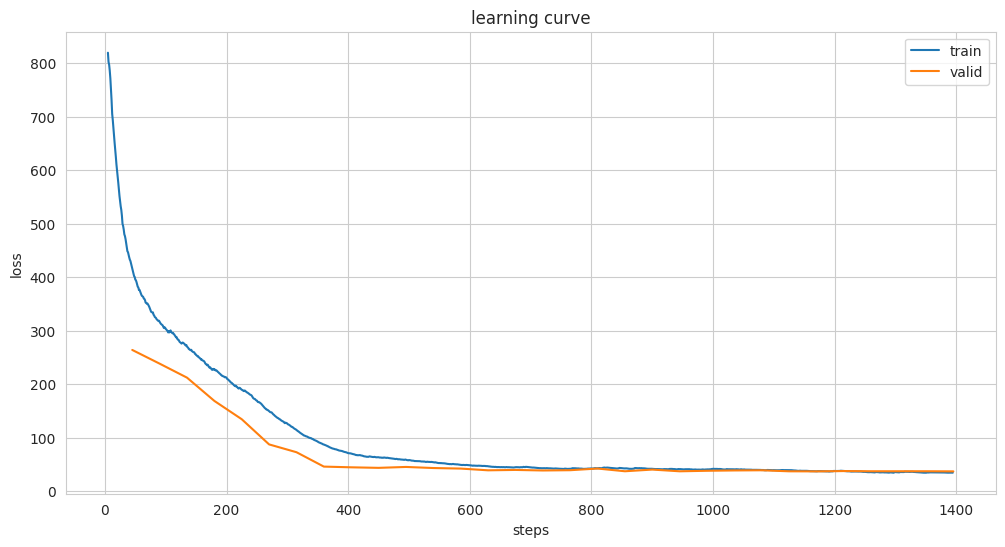

In [20]:
learn.recorder.plot_loss()

## Test Set Evaluation

In [21]:
dl_test = learn.dls.test_dl(test_df)
preds, targets = learn.get_preds(dl=dl_test)
preds_np = preds.numpy().flatten()
targets_np = targets.numpy().flatten()

mae = mean_absolute_error(targets_np, preds_np)
rmse_val = np.sqrt(mean_squared_error(targets_np, preds_np))
r2 = r2_score(targets_np, preds_np)

print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse_val:.4f}")
print(f"R²:   {r2:.4f}")

MAE:  4.9134
RMSE: 6.2447
R²:   0.9205


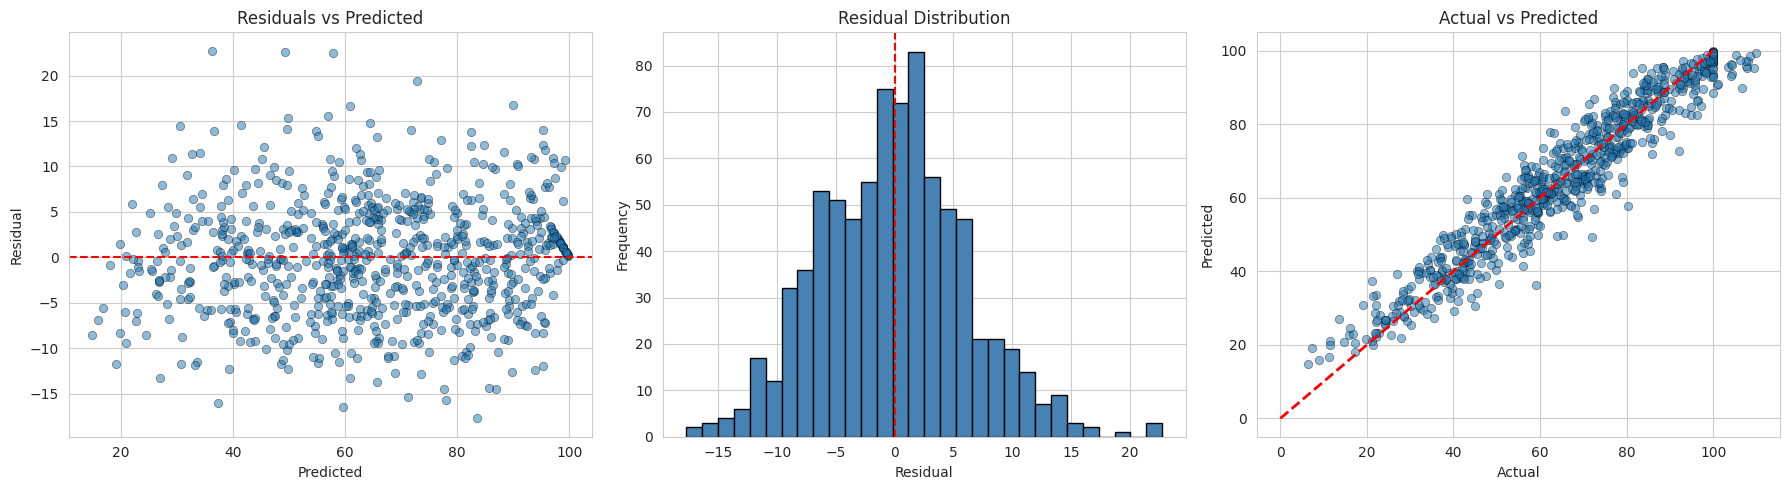

Residual mean: -0.1477
Residual std:  6.2430


In [22]:
residuals = targets_np - preds_np

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(preds_np, residuals, alpha=0.5, edgecolors='k', linewidths=0.5)
axes[0].axhline(y=0, color='r', linestyle='--')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Residual')
axes[0].set_title('Residuals vs Predicted')

axes[1].hist(residuals, bins=30, edgecolor='black', color='steelblue')
axes[1].axvline(x=0, color='r', linestyle='--')
axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Residual Distribution')

axes[2].scatter(targets_np, preds_np, alpha=0.5, edgecolors='k', linewidths=0.5)
axes[2].plot([0, 100], [0, 100], 'r--', linewidth=2)
axes[2].set_xlabel('Actual')
axes[2].set_ylabel('Predicted')
axes[2].set_title('Actual vs Predicted')

plt.tight_layout()
plt.show()

print(f"Residual mean: {residuals.mean():.4f}")
print(f"Residual std:  {residuals.std():.4f}")

In [23]:
test_results = test_df.copy()
test_results['predicted'] = preds_np
test_results['error'] = abs(test_results['grades'] - preds_np)

print("Worst predictions:")
print(test_results.nlargest(10, 'error')[['grades', 'predicted', 'error', 'gaming_hours', 'study_hours', 'sleep_hours']])

print(f"\nWithin 5 points:  {(test_results['error'] <= 5).mean() * 100:.2f}%")
print(f"Within 10 points: {(test_results['error'] <= 10).mean() * 100:.2f}%")
print(f"Within 15 points: {(test_results['error'] <= 15).mean() * 100:.2f}%")

Worst predictions:
         grades  predicted      error  gaming_hours  study_hours  sleep_hours
500   59.054442  36.320042  22.734401          5.87         2.70         4.85
611   71.979882  49.356388  22.623494          6.38         6.12         4.84
211   80.258338  57.778030  22.480308          6.30         7.10         6.78
247   92.219485  72.804443  19.415042          5.63         7.30         6.30
276   65.830000  83.532219  17.702219          4.89         9.02         5.77
4    106.774359  89.973213  16.801146          1.93         8.10         4.78
32    77.592840  60.921318  16.671522          3.43         3.95         6.68
723   43.110000  59.553127  16.443127          4.50         3.62         7.67
748   21.280000  37.310211  16.030211          6.08         2.86         5.60
132   62.250000  77.985016  15.735016          2.52         5.42         5.92

Within 5 points:  56.62%
Within 10 points: 88.88%
Within 15 points: 98.38%


## Feature Importance

In [24]:
learn.show_results()

,gaming_genre,gender,stress_level,age,gaming_hours,sleep_hours,study_hours,attendance,social_activity,addiction_score,reaction_time_ms,device_usage,grades,grades_pred
0,2.0,1.0,2.0,0.008716,1.395793,0.964157,-0.012306,1.077172,1.421970,2.164319,-1.668635,1.094162,56.080002,50.595482
1,2.0,2.0,2.0,0.781072,1.516854,0.354501,-1.431234,-0.466297,-1.073458,1.537845,-1.851047,2.100560,28.307291,21.639576
2,1.0,2.0,3.0,-1.149819,-0.796272,-0.192804,-0.748908,-0.294897,1.685377,-1.711864,0.370572,-0.607834,60.470001,65.986809
3,3.0,1.0,1.0,-0.377462,1.140701,-0.767820,1.073214,-0.131288,-1.177434,0.827841,-1.009773,0.672363,63.423286,73.341904
4,2.0,1.0,3.0,1.167251,-1.172425,0.493059,1.743909,1.039082,-0.172331,-0.991916,1.817279,-0.707734,100.000000,99.377716
5,3.0,2.0,3.0,0.781072,-1.496695,-0.227444,0.383133,0.601925,-1.662656,-1.009815,1.588243,-0.911233,94.906395,90.727341
6,2.0,2.0,2.0,-0.763641,0.881285,-0.968729,-0.760539,0.006352,-0.338693,0.917337,-0.968253,-0.063935,27.170000,37.136761
7,1.0,1.0,1.0,-1.535997,-1.159454,-0.546127,1.344593,-0.386657,0.860499,-1.542815,1.140039,-1.906531,100.000000,96.097282
8,3.0,2.0,3.0,-0.763641,-0.363912,1.102715,0.251320,-0.063766,0.590161,-0.206338,0.083341,-1.062933,77.739998,79.926247


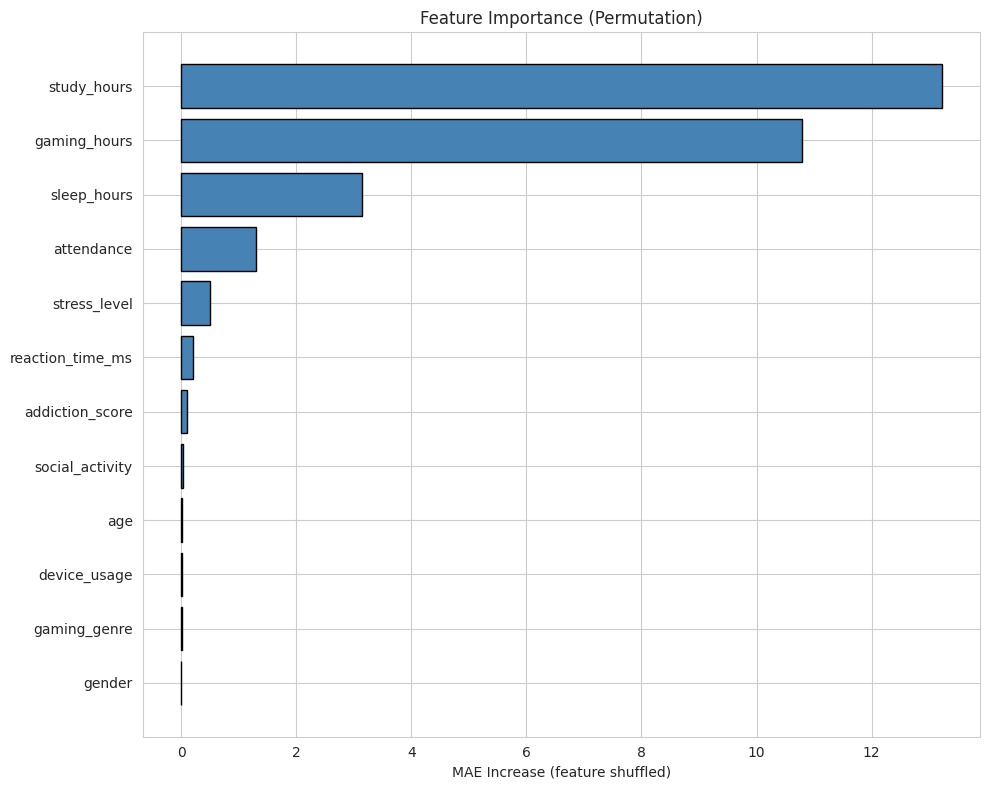

In [25]:
from sklearn.inspection import permutation_importance

dl_val = learn.dls.valid
val_preds_before, val_targets = learn.get_preds(dl=dl_val)
val_preds_np = val_preds_before.numpy().flatten()
val_targets_np = val_targets.numpy().flatten()

importances = []
feature_names = cont_names + cat_names

for col in cont_names:
    shuffled = test_df.copy()
    shuffled[col] = shuffled[col].sample(frac=1, random_state=42).reset_index(drop=True)
    dl_shuf = learn.dls.test_dl(shuffled)
    shuf_preds, _ = learn.get_preds(dl=dl_shuf)
    shuf_mae = mean_absolute_error(targets_np, shuf_preds.numpy().flatten())
    importances.append(shuf_mae - mae)

for col in cat_names:
    shuffled = test_df.copy()
    shuffled[col] = shuffled[col].sample(frac=1, random_state=42).reset_index(drop=True)
    dl_shuf = learn.dls.test_dl(shuffled)
    shuf_preds, _ = learn.get_preds(dl=dl_shuf)
    shuf_mae = mean_absolute_error(targets_np, shuf_preds.numpy().flatten())
    importances.append(shuf_mae - mae)

fi_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(fi_df['Feature'], fi_df['Importance'], color='steelblue', edgecolor='black')
plt.xlabel('MAE Increase (feature shuffled)')
plt.title('Feature Importance (Permutation)')
plt.tight_layout()
plt.show()

## Predictions by Gaming Genre

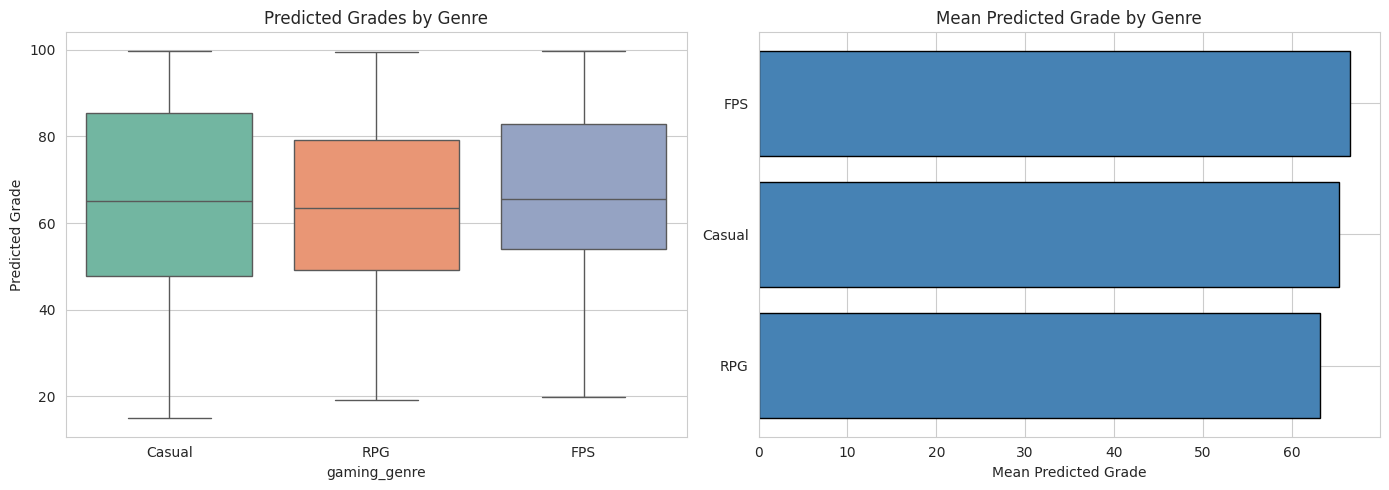

In [26]:
pred_df = test_df.copy()
pred_df['predicted'] = preds_np

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=pred_df, x='gaming_genre', y='predicted', palette='Set2', ax=axes[0])
axes[0].set_title('Predicted Grades by Genre')
axes[0].set_ylabel('Predicted Grade')

genre_means = pred_df.groupby('gaming_genre')['predicted'].mean().sort_values(ascending=True)
axes[1].barh(genre_means.index, genre_means.values, color='steelblue', edgecolor='black')
axes[1].set_title('Mean Predicted Grade by Genre')
axes[1].set_xlabel('Mean Predicted Grade')

plt.tight_layout()
plt.show()

## K-Fold Cross-Validation

In [27]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
fold_metrics = []

print("5-Fold Cross-Validation")
print("=" * 60)

for fold, (train_idx, val_idx) in enumerate(kf.split(main_df)):
    train_fold = main_df.iloc[train_idx].reset_index(drop=True)
    val_fold = main_df.iloc[val_idx].reset_index(drop=True)

    dls_fold = TabularDataLoaders.from_df(
        train_fold,
        valid_df=val_fold,
        path='./',
        y_names=y_names,
        cat_names=cat_names,
        cont_names=cont_names,
        procs=procs,
        seed=42,
        bs=128
    )

    learn_fold = tabular_learner(
        dls_fold,
        layers=[300, 150],
        metrics=[rmse],
        y_range=(0, 100),
        config={'ps': 0.1},
        wd=0.1
    )

    early_stop_fold = EarlyStoppingCallback(monitor='valid_loss', patience=5)
    learn_fold.fit_one_cycle(50, lr_max=suggestions.valley, cbs=early_stop_fold)

    dl_val_fold = learn_fold.dls.valid
    preds_val, targets_val = learn_fold.get_preds(dl=dl_val_fold)
    pv = preds_val.numpy().flatten()
    tv = targets_val.numpy().flatten()

    f_mae = mean_absolute_error(tv, pv)
    f_rmse = np.sqrt(mean_squared_error(tv, pv))
    f_r2 = r2_score(tv, pv)

    fold_metrics.append({'fold': fold + 1, 'MAE': f_mae, 'RMSE': f_rmse, 'R2': f_r2})
    print(f"Fold {fold+1}: MAE={f_mae:.4f}, RMSE={f_rmse:.4f}, R²={f_r2:.4f}")

metrics_df = pd.DataFrame(fold_metrics)
print(f"\nMean MAE:  {metrics_df['MAE'].mean():.4f} (+/- {metrics_df['MAE'].std():.4f})")
print(f"Mean RMSE: {metrics_df['RMSE'].mean():.4f} (+/- {metrics_df['RMSE'].std():.4f})")
print(f"Mean R²:   {metrics_df['R2'].mean():.4f} (+/- {metrics_df['R2'].std():.4f})")

5-Fold Cross-Validation


epoch,train_loss,valid_loss,_rmse,time
0,530.171326,336.653534,18.348122,00:00
1,389.905334,266.563354,16.326769,00:00
2,319.739960,220.161453,14.837839,00:00
3,272.773926,190.586502,13.805307,00:00
4,233.890793,167.301758,12.934518,00:00
5,195.504623,123.365967,11.107024,00:00
6,153.008621,81.810501,9.044916,00:00
7,115.034836,55.365875,7.440825,00:00
8,91.751884,52.011589,7.211906,00:00
9,78.285393,53.988300,7.347673,00:00


No improvement since epoch 23: early stopping


Fold 1: MAE=4.7289, RMSE=5.9166, R²=0.9361


epoch,train_loss,valid_loss,_rmse,time
0,466.586792,395.820770,19.895247,00:00
1,380.002502,291.342987,17.068771,00:00
2,330.085297,255.460938,15.983146,00:00
3,285.980377,201.075867,14.180122,00:00
4,250.012894,184.210632,13.572422,00:00
5,211.369324,133.893906,11.571254,00:00
6,174.800186,120.593925,10.981527,00:00
7,132.417206,61.300491,7.829463,00:00
8,102.629295,52.594685,7.252219,00:00
9,83.343582,59.943901,7.742345,00:00


...

No improvement since epoch 20: early stopping


Fold 4: MAE=4.8544, RMSE=6.1281, R²=0.9244


epoch,train_loss,valid_loss,_rmse,time
0,490.538330,220.925720,14.863569,00:00
1,379.133270,226.808426,15.060161,00:00
2,318.597290,214.743652,14.654135,00:00
3,273.375122,178.054916,13.343722,00:00
4,231.316971,137.752457,11.736799,00:00
5,192.941086,106.952606,10.341789,00:00
6,151.379532,69.496773,8.336473,00:00
7,116.716797,50.222027,7.086750,00:00
8,93.955391,55.985725,7.482361,00:00
9,78.448471,46.706707,6.834230,00:00


No improvement since epoch 26: early stopping


Fold 5: MAE=4.6112, RMSE=5.8479, R²=0.9336

Mean MAE:  4.7853 (+/- 0.1215)
Mean RMSE: 6.0225 (+/- 0.1649)
Mean R²:   0.9304 (+/- 0.0048)


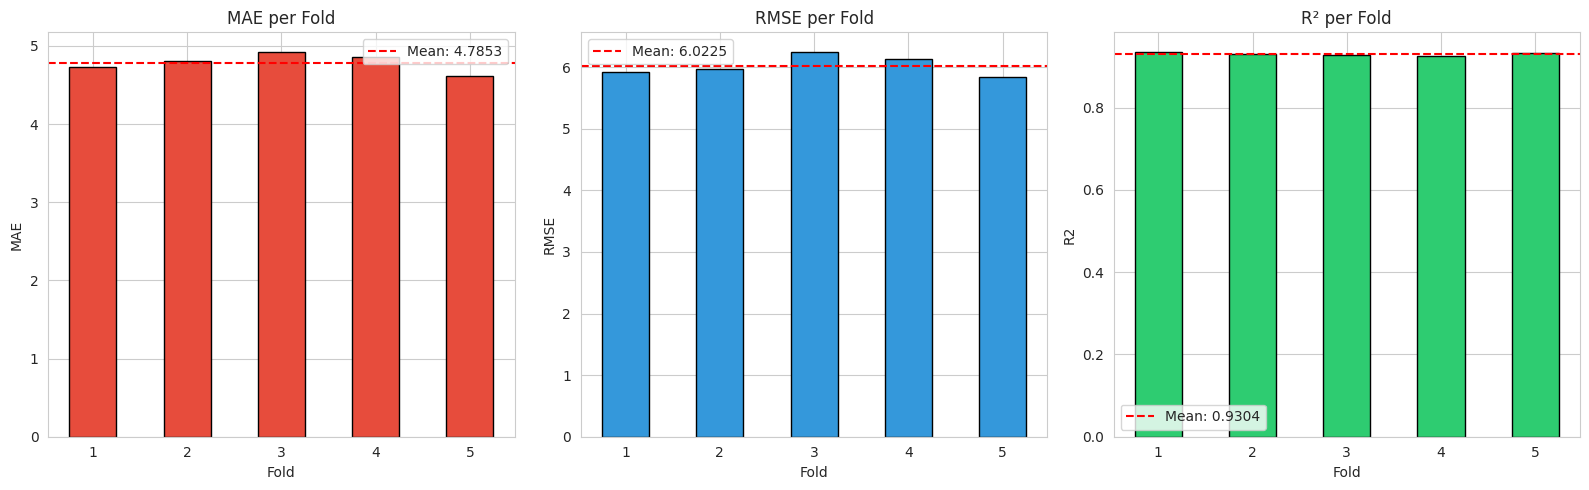

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics = ['MAE', 'RMSE', 'R2']
titles = ['MAE per Fold', 'RMSE per Fold', 'R² per Fold']
colors = ['#e74c3c', '#3498db', '#2ecc71']

for i, (m, t, c) in enumerate(zip(metrics, titles, colors)):
    axes[i].bar(metrics_df['fold'], metrics_df[m], color=c, edgecolor='black', width=0.5)
    axes[i].axhline(y=metrics_df[m].mean(), color='r', linestyle='--', label=f'Mean: {metrics_df[m].mean():.4f}')
    axes[i].set_title(t)
    axes[i].set_xlabel('Fold')
    axes[i].set_ylabel(m)
    axes[i].legend()

plt.tight_layout()
plt.show()

## Save Model

In [29]:
os.makedirs('models', exist_ok=True)
learn.save('model')
learn.export('models/model.pkl')
print("Model saved to models/model.pkl")

Model saved to models/model.pkl
